In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

In [2]:
#For plotting
axes_width = 2
label_size = 20
tick_size = 18
padding = 10

Variants affecting per codon

In [3]:
#Load STG only data
parquet_dir = "/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/parquets/"
AF_FILTERED = pd.read_parquet(f"{parquet_dir}AF_filtered_STG_final.parquet")
DP = pd.read_parquet(f"{parquet_dir}DP_filtered_STG_final.parquet")
metadata_filtered = pd.read_parquet(f"{parquet_dir}metadata_filtered_repeats_germline_freq.parquet")
metadata_filtered['age_at_death'] = metadata_filtered['age_at_death'].astype(str).str.replace(',', '.', regex=False)
GQ = pd.read_parquet(f"{parquet_dir}GQ_filtered_STG_final.parquet")
NGT_final = pd.read_parquet(f"{parquet_dir}NGT_filtered_STG_final.parquet")

In [4]:
# Select TARDBP only
annotations = pd.read_csv('/results/rr/study/hg38s/study232-missionbio_TDP-C/outputs/vaf30/Annotations_vafhet30.csv', sep='\t', header=0) 
annotations = annotations[annotations['variant_id'].isin(NGT_final.columns)]
annotations = annotations[annotations['SYMBOL']=="TARDBP"]
tardbp_vars = annotations['variant_id'].to_list()

NGT = NGT_final[tardbp_vars].copy()
DP = DP[tardbp_vars].copy()
AF_FILTERED = AF_FILTERED[tardbp_vars].copy()
GQ = GQ[tardbp_vars].copy()

NGT['sample_identifier'] = NGT.index.map(metadata_filtered['ID'])
NGT['sample_id']  = NGT.index.map(metadata_filtered['sample_id'])
NGT['sample_type'] =  NGT.index.map(metadata_filtered['sample_type'])
NGT['age_at_death'] = NGT.index.map(metadata_filtered['age_at_death'])
NGT['age_at_death'] = NGT['age_at_death'].str.replace(',', '.').astype(float)
NGT['hemisphere'] = NGT.index.map(metadata_filtered['hemisphere'])

/tmp/ipykernel_365207/2516102536.py:2: DtypeWarning: Columns (37,39,76) have mixed types. Specify dtype option on import or set low_memory=False.
  annotations = pd.read_csv('/results/rr/study/hg38s/study232-missionbio_TDP-C/outputs/vaf30/Annotations_vafhet30.csv', sep='\t', header=0)


In [5]:
NGT_controls = NGT[NGT['sample_type'] == "C"]
NGT_patients = NGT[NGT['sample_type'] == "P"]
annotations.set_index('variant_id', inplace=True)
counts = pd.DataFrame((NGT_patients.iloc[:, :-5].isin([1, 2])).sum())
counts.columns = ['cell_count_patients']
counts['mutation_freq_P'] = counts['cell_count_patients']/NGT_patients.shape[0]*100
ann = pd.merge(annotations, counts, left_index=True, right_index=True, how='inner') 

counts_C = pd.DataFrame((NGT_controls.iloc[:, :-5].isin([1, 2])).sum())
counts_C.columns = ['cell_count_controls']
counts_C['mutation_freq_C'] = counts_C['cell_count_controls']/NGT_controls.shape[0]*100
ann = pd.merge(ann, counts_C, left_index=True, right_index=True, how='inner') 
ann["total_cells"] = ann["cell_count_patients"] + ann["cell_count_controls"]
ann['total_freq'] = ann["total_cells"]/NGT.shape[0]

In [6]:
def annotate_spliceai_effect(df: pd.DataFrame) -> pd.DataFrame:
    cols = ['SpliceAI_pred_DS_AG','SpliceAI_pred_DS_AL','SpliceAI_pred_DS_DG','SpliceAI_pred_DS_DL']
    labels = ['acceptor_gain', 'acceptor_loss','donor_gain','donor_loss']

    # Ensure numeric (handles '.', strings, NaN etc.)
    ds_matrix = (df[cols].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy())
    # Index of max score per row
    max_idx = ds_matrix.argmax(axis=1)
    # Max score per row
    max_score = ds_matrix.max(axis=1)

    # Map severity
    severity = np.select(
        [max_score >= 0.8,max_score >= 0.5,max_score >= 0.2],
        ['high','moderate','low'],
        default='none'
    )

    # Map effect
    effect = [labels[i] for i in max_idx]
    # If all four scores are 0 → effect should be none
    effect = np.where(max_score == 0, 'none', effect)
    df['spliceai_severity'] = severity
    df['spliceai_effect'] = effect

    return df
ann = annotate_spliceai_effect(ann)
def categorize_hc_lof(row) -> str:
    lof_flag = str(row.get("LoF", "")).upper()
    spliceai_sev = str(row.get("spliceai_severity", "")).lower()
    if lof_flag in {"HC", "OS"} or spliceai_sev == "high":
        return "Yes"
    return np.nan

LOF = {
    "stop_gained", "frameshift_variant", "stop_gained&frameshift_variant",
    "splice_acceptor_variant", "splice_donor_variant",
    "stop_gained&splice_region_variant", "frameshift_variant&splice_region_variant"
}

indel_terms = [
    "frameshift_variant",
    "frameshift_variant&splice_region_variant",
    "stop_gained&frameshift_variant",
    "stop_gained&inframe_deletion",
    "inframe_deletion",
    "inframe_insertion",
    "frameshift_variant&stop_lost",
    "frameshift_variant&start_lost",
]

non_coding_terms = [
    "intron_variant",
    "splice_polypyrimidine_tract_variant&intron_variant",
    "splice_region_variant&splice_polypyrimidine_tract_variant&intron_variant",
    "splice_donor_region_variant&intron_variant",
    "splice_region_variant&5_prime_UTR_variant",
    "splice_donor_5th_base_variant&intron_variant",
    "splice_region_variant&intron_variant",
    "3_prime_UTR_variant",
    "5_prime_UTR_variant",
]

splice_site_terms = ["splice_acceptor_variant", "splice_donor_variant"]
missense_terms = ["missense_variant", "missense_variant&splice_region_variant"]
nonsense_terms = ["stop_gained", "stop_gained&splice_region_variant", "stop_gained&frameshift_variant", "stop_gained&inframe_deletion"]
frameshift_terms = ["frameshift_variant", "frameshift_variant&splice_region_variant", "frameshift_variant&stop_lost", "frameshift_variant&start_lost"]
synonymous_terms = ['synonymous_variant', 'stop_retained_variant', 'splice_region_variant&synonymous_variant']
nonsynonymous_terms = [
    "start_lost",
    "missense_variant",
    "frameshift_variant",
    "stop_gained",
    "missense_variant&splice_region_variant",
    "inframe_deletion",
    "frameshift_variant&splice_region_variant",
    "inframe_insertion",
    "stop_gained&splice_region_variant",
    "stop_lost",
    "stop_gained&frameshift_variant",
    "frameshift_variant&stop_lost",
    "stop_gained&inframe_deletion",
    "frameshift_variant&start_lost",
]

ann["HC_LOF"] = ann.apply(categorize_hc_lof,  axis=1)

lengths_ref = ann['REF'].apply(len)
length_alt = ann['ALT'].apply(len)
indels = (lengths_ref[lengths_ref >1].index.to_list()) + (length_alt[length_alt >1].index.to_list()) # Count total number of indels
indels = list(set(indels))
ann_all_snv = ann.drop(index = indels) # To calculate total number of SNVs
ann_all_indels = ann.loc[indels]

ann_coding = ann[~ann['Consequence'].isin(non_coding_terms)]
ann_indel = ann_coding[ann_coding['Consequence'].isin(indel_terms)] #Indels in coding regions 
ann_snv = ann_coding[~ann_coding['Consequence'].isin(indel_terms)] # SNVs in coding regions

ann_nonsyn = ann_coding[ann_coding['Consequence'].isin(nonsynonymous_terms)]
ann_syn = ann_coding[ann_coding['Consequence'].isin(synonymous_terms)]
ann_missense = ann_coding[ann_coding['Consequence'].isin(missense_terms)]
ann_nonsense = ann_coding[ann_coding['Consequence'].isin(nonsense_terms)]
ann_frameshift = ann_coding[ann_coding['Consequence'].isin(frameshift_terms)]
ann_splicesite = ann_coding[ann_coding['Consequence'].isin(splice_site_terms)]
ann_startloss = ann_coding[ann_coding['Consequence'].isin(["start_lost"])]
ann_stoploss = ann_coding[ann_coding['Consequence'].isin(["stop_lost"])]
ann_lof = ann_coding[ann_coding['Consequence'].isin(list(LOF))]
ann_lof_hf = ann_lof[ann_lof['HC_LOF']=="Yes"]
cadd_above20 = ann_snv[ann_snv['CADD_PHRED'] >= 20]


In [7]:
print("All coding variants:", ann_coding.shape[0])
print("Synonymous:", ann_syn.shape[0])
print("Non-syn", ann_nonsyn.shape[0])
print("Nonsense:", ann_nonsense.shape[0])
print("Missense:", ann_missense.shape[0])
print("Frameshift", ann_frameshift.shape[0])
print("LOF:", ann_lof.shape[0])

All coding variants: 1503
Synonymous: 411
Non-syn 1079
Nonsense: 58
Missense: 964
Frameshift 51
LOF: 122


In [8]:
ann_coding_snvs = ann_coding[ann_coding['Consequence'].isin(['start_lost', 'missense_variant', 'synonymous_variant',
       'stop_gained',
       'missense_variant&splice_region_variant',
       'splice_region_variant&synonymous_variant',
       'stop_gained&splice_region_variant'])]


In [9]:
cols = ["cDNA_position", "Protein_position"]
ann_coding_snvs = ann_coding_snvs.copy()
ann_coding_snvs[cols] = ann_coding_snvs[cols].apply(pd.to_numeric, errors="coerce")

In [10]:
mapping = {
    "missense_variant": "Missense",
    "missense_variant&splice_region_variant": "Missense",
    "synonymous_variant": "Synonymous",
    "splice_region_variant&synonymous_variant": "Synonymous",
    "stop_retained_variant" : "Synonymous",
    "stop_gained": "Stop gained",
    "stop_gained&splice_region_variant": "Stop gained",
    "start_lost": "Start lost"
}
ann_coding_snvs = ann_coding_snvs.copy()
ann_coding_snvs.loc[:,"Consequence_simplified"] = ann_coding_snvs["Consequence"].replace(mapping)

In [11]:
variant_types = ['Missense', 'Synonymous', 'Stop gained', 'Start lost']
grouped_data = {}

for variant in variant_types:
    # Filter the rows where 'Consequence' matches the variant type
    df = ann_coding_snvs 
    variant_counts = df[df['Consequence_simplified'] == variant].groupby('Protein_position').size()
    grouped_data[variant] = variant_counts.reindex(df['Protein_position'].unique(), fill_value=0)

grouped_df = pd.DataFrame(grouped_data)
grouped_df['codon'] = grouped_df.index
grouped_df['position'] = grouped_df.index
grouped_df['position'] = grouped_df['position'].astype(int)
grouped_df = grouped_df.reset_index().rename(columns={'index': 'position'})


In [12]:
codons_covered = [
    (1, 66),
    (80, 134),
    (134, 181),
    (181, 238),
    (238, 246),
    (264, 339),
    #(264, 291),
    #(296, 339),
    (352, 415),
]

labels = ["AMPL265969",
"AMPL283008",
"AMPL265971",
"AMPL22878",
"AMPL283011",
"AMPL265974",
"AMPL265975"]

domains = [
    (1, 82),#NTD
    (106, 176), #RRM1
    (192, 262), #RRM2
    (274, 414) #CTD
]

labelsdomians = ["NTD", 
"RRM1",
"RRM2",
"C-terminal domain"]

nls_nes = [
    (82, 98), #NLS
    (239, 250) #NES
]

nls_nes_labels = ["NLS","NES"]

ann.loc[(ann['Protein_position']== "175-176"), 'Protein_position'] = 175
ann['Protein_position'] = pd.to_numeric(ann['Protein_position'])

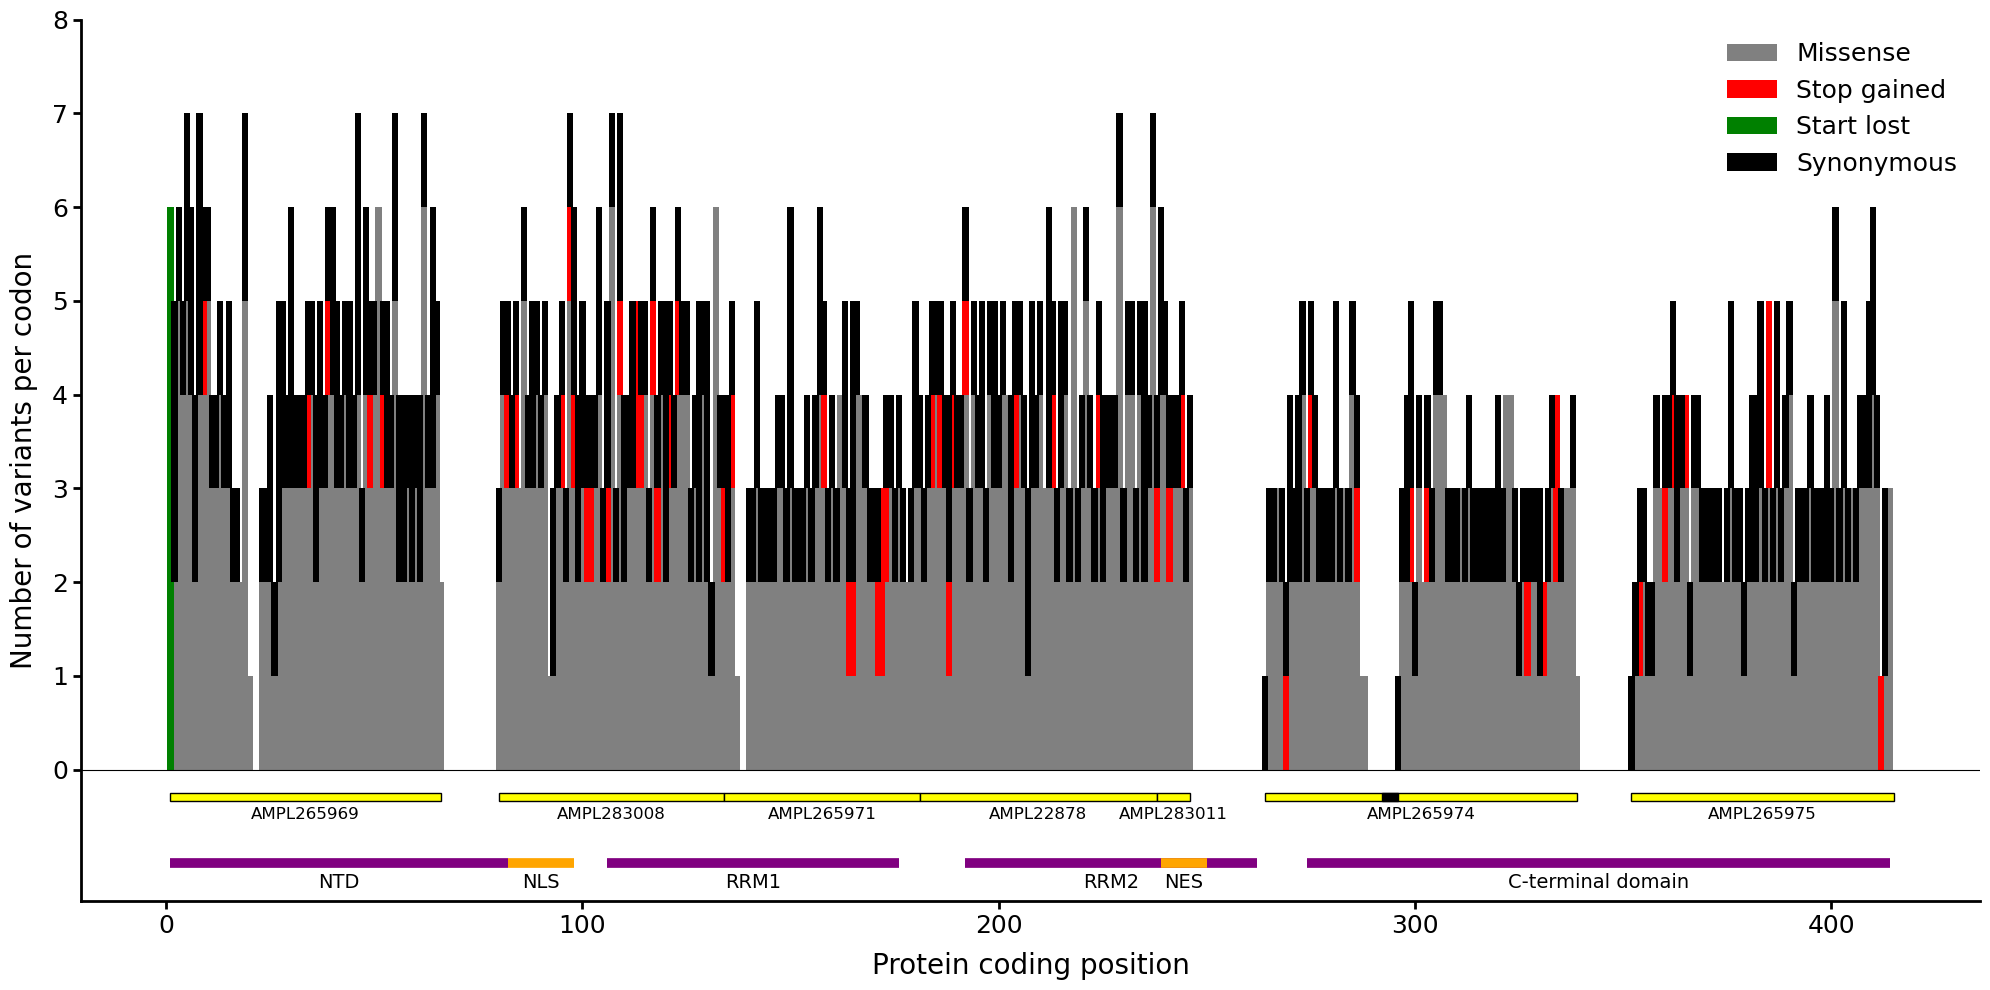

In [13]:
# Plot the variant bar plot
import matplotlib.patches as patches
bar_width = 1.5
fig, ax = plt.subplots(figsize=(20, 10))
codon_grouped_df = grouped_df.groupby('codon')[['Missense', 'Stop gained', 'Start lost', 'Synonymous']].sum()

# Plot stacked bars
ax.bar(codon_grouped_df.index, codon_grouped_df['Missense'], color='grey', label='Missense', width=bar_width)
ax.bar(codon_grouped_df.index, codon_grouped_df['Stop gained'], 
       bottom=codon_grouped_df['Missense'], color='red', label='Stop gained', width=bar_width)
ax.bar(codon_grouped_df.index, codon_grouped_df['Start lost'], 
       bottom=codon_grouped_df['Missense'] + codon_grouped_df['Stop gained'], color='green', label='Start lost', width=bar_width)
ax.bar(codon_grouped_df.index, codon_grouped_df['Synonymous'], 
       bottom=codon_grouped_df['Missense'] + codon_grouped_df['Stop gained'] + codon_grouped_df['Start lost'], 
       color='black', label='Synonymous', width=bar_width)


for (start, end), label in zip(codons_covered, labels):

    width = end - start

    rect = patches.Rectangle(
        (start, -0.33),    
        width,             
        0.08,               
        facecolor='yellow',  
        edgecolor='black',   
        linewidth=1
    )
    ax.add_patch(rect)

    # Compute center
    center = (start + end) / 2

    # Label
    ax.text(center, -0.4, label, ha='center', va='top', fontsize=12)

ax.add_patch(patches.Rectangle(
        (292, -0.33),    
        (296-292),             
        0.08,               
        facecolor='black',  
        edgecolor='black',   
        linewidth=1
    ))


# Draw horizontal bars and labels
for (start, end), label in zip(domains, labelsdomians):
    ax.hlines(y=-1, xmin=start, xmax=end, color='purple', linewidth=7)

    center = (start + end) / 2
    # Add label slightly below the bar
    ax.text(center, -1.1, label, ha='center', va='top', fontsize=14)
    
for (start, end), label in zip(nls_nes, nls_nes_labels):
    ax.hlines(y=-1, xmin=start, xmax=end, color='orange', linewidth=7)

    center = (start + end) / 2
    # Add label slightly below the bar
    ax.text(center, -1.1, label, ha='center', va='top', fontsize=14)

yticks = ax.get_yticks()
ax.set_yticks([y for y in yticks if y >= 0])
ax.set_xlabel('Protein coding position', fontsize=label_size, labelpad=padding)
ax.set_ylabel('Number of variants per codon', fontsize=label_size, labelpad=padding)
ax.tick_params(axis='both', which='major', bottom=True, left=True, length=6, width=axes_width, direction='out', labelsize=tick_size)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(axes_width)
ax.spines['bottom'].set_linewidth(axes_width)

ax.axhline(0, color='black', linewidth=0.8)
ax.legend(fontsize=18, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel2/figureA.png", dpi= 600, bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel2/figureA.svg", bbox_inches="tight", transparent=True)
plt.show()


Plot the variant distribution for TARDBP (per sample)

In [14]:
parquet_dir = "/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/parquets/"
AF_FILTERED = pd.read_parquet(f"{parquet_dir}AF_filtered_final.parquet")
DP = pd.read_parquet(f"{parquet_dir}DP_filtered_final.parquet")
metadata_filtered = pd.read_parquet(f"{parquet_dir}metadata_filtered_repeats_germline_freq.parquet")
metadata_filtered['age_at_death'] = metadata_filtered['age_at_death'].astype(str).str.replace(',', '.', regex=False)
GQ = pd.read_parquet(f"{parquet_dir}GQ_filtered_final.parquet")
NGT_final = pd.read_parquet(f"{parquet_dir}NGT_filtered_final.parquet")

In [15]:
# Select TARDBP only
annotations = pd.read_csv('/results/rr/study/hg38s/study232-missionbio_TDP-C/outputs/vaf30/Annotations_vafhet30.csv', sep='\t', header=0) 
annotations = annotations[annotations['variant_id'].isin(NGT_final.columns)]
annotations = annotations[annotations['SYMBOL']=="TARDBP"]
tardbp_vars = annotations['variant_id'].to_list()

/tmp/ipykernel_365207/1003551456.py:2: DtypeWarning: Columns (37,39,76) have mixed types. Specify dtype option on import or set low_memory=False.
  annotations = pd.read_csv('/results/rr/study/hg38s/study232-missionbio_TDP-C/outputs/vaf30/Annotations_vafhet30.csv', sep='\t', header=0)


In [16]:
NGT = NGT_final[tardbp_vars].copy()
DP = DP[tardbp_vars].copy()
AF_FILTERED = AF_FILTERED[tardbp_vars].copy()
GQ = GQ[tardbp_vars].copy()

NGT['sample_identifier'] = NGT.index.map(metadata_filtered['ID'])
NGT['sample_id']  = NGT.index.map(metadata_filtered['sample_id'])
NGT['sample_type'] =  NGT.index.map(metadata_filtered['sample_type'])
NGT['age_at_death'] = NGT.index.map(metadata_filtered['age_at_death'])
NGT['age_at_death'] = NGT['age_at_death'].str.replace(',', '.').astype(float)
NGT['hemisphere'] = NGT.index.map(metadata_filtered['hemisphere'])

In [17]:
ids = NGT['sample_identifier'].unique()
results = []  
for sample in ids:
    # Subset this sample
    sub = NGT.loc[NGT['sample_identifier'] == sample]
    sub_variants = sub.iloc[:, :-5]  

    n_cells = sub_variants.shape[0]

    mutated = sub_variants.isin([1, 2])          
    callable_ = sub_variants.isin([0, 1, 2])   


    mut_cell_count = mutated.sum(axis=0)       
    total_callable = callable_.sum(axis=0)    

    with np.errstate(divide="ignore", invalid="ignore"):
        freq = np.where(
            total_callable.to_numpy() > 0,
            (mut_cell_count.to_numpy() / total_callable.to_numpy()) * 100,
            0.0,
        )

    freq = pd.Series(freq, index=sub_variants.columns)

    high_mut = mut_cell_count[mut_cell_count > 8]
    if not high_mut.empty:
        for var in high_mut.index:
            print(sample, var)

    results.append({
        "sample_identifier": sample,
        "max_freq": float(freq.max()),
        "max_cell": int(mut_cell_count.max()),
        "n_cells": int(n_cells),
    })

max_freq_var_per_sample = pd.DataFrame(results).set_index("sample_identifier")
max_freq_var_per_sample.drop(['Q5_C', 'Q4_P'], inplace=True)

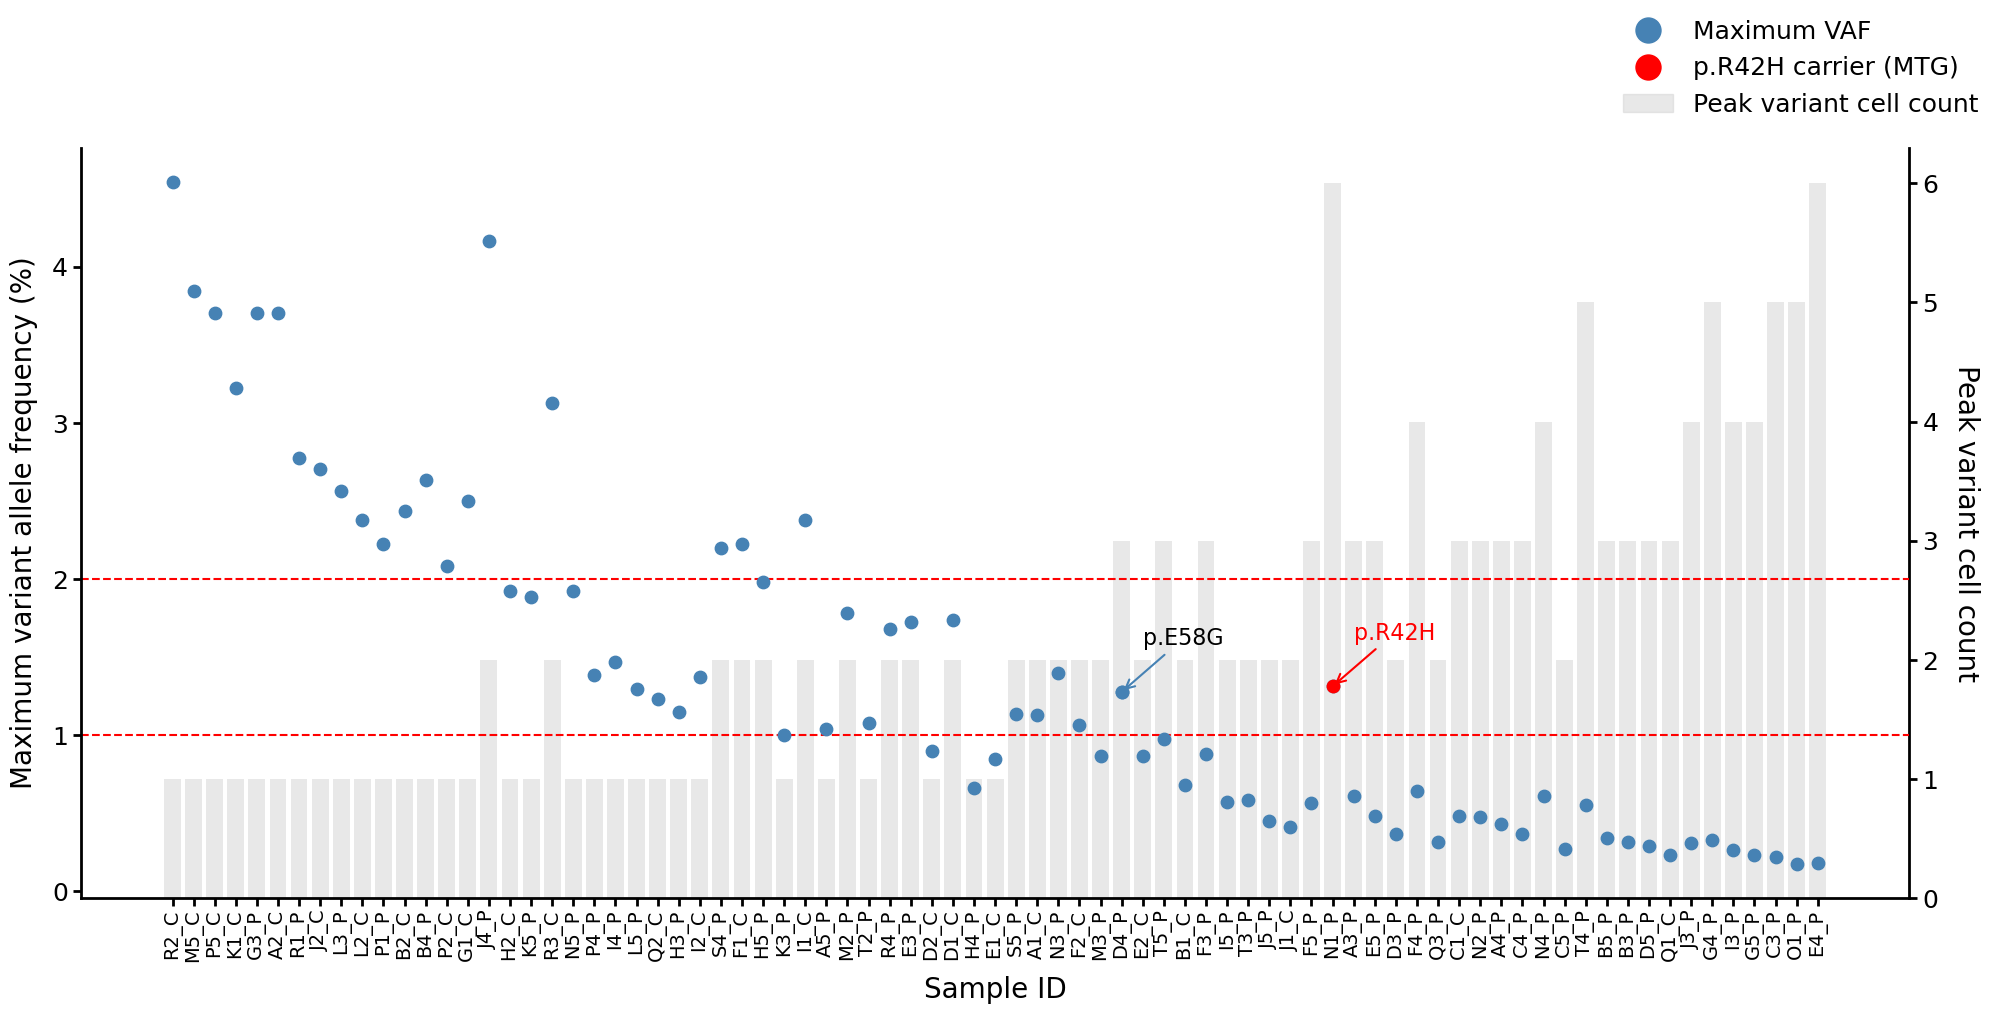

In [18]:
df_plot = max_freq_var_per_sample.copy()
x = np.arange(len(df_plot))

order    = df_plot.sort_values('n_cells', ascending=True).index
df_plot  = df_plot.loc[order]

fig, ax1 = plt.subplots(figsize=(20, 10))
ax2 = ax1.twinx()

# --- bars on right axis ---
ax2.bar(x, df_plot['max_cell'], color='lightgrey', alpha=0.5, zorder=1, width=0.8)
ax2.set_ylabel('Peak variant cell count', fontsize=label_size, labelpad=30, rotation=270)
ax2.yaxis.set_label_position("right")
ax2.tick_params(axis='y', labelsize=tick_size, length=6, width=axes_width)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['right'].set_linewidth(2)

# --- scatter on left axis ---
ax1.scatter(x, df_plot['max_freq'], color='steelblue', zorder=3, s=80)
ax1.axhline(2, linestyle='--', color='red', linewidth=1.5)
ax1.axhline(1, linestyle='--', color='red', linewidth=1.5)
ax1.set_ylabel('Maximum variant allele frequency (%)', fontsize=label_size, labelpad=padding)
ax1.set_xlabel('Sample ID', fontsize=label_size, labelpad=padding)
ax1.tick_params(axis='y', labelsize=tick_size, length=6, width=axes_width, direction='out')
ax1.tick_params(axis='x', labelsize=tick_size, length=6, width=axes_width, direction='out')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)

# --- highlight N1_P in red ---
highlight = 'N1_P'
if highlight in df_plot.index:
    hx = list(df_plot.index).index(highlight)
    hy = df_plot.loc[highlight, 'max_freq']
    ax1.scatter(hx, hy, color='red', zorder=4, s=80)
    ax1.annotate('p.R42H', xy=(hx, hy), xytext=(hx + 1, hy + 0.3),
                 fontsize=(tick_size-2), color='red',
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# --- highlight D4_P ---
highlight = 'D4_P'
if highlight in df_plot.index:
    hx = list(df_plot.index).index(highlight)
    hy = df_plot.loc[highlight, 'max_freq']
    ax1.scatter(hx, hy, color='steelblue', zorder=4, s=80)
    ax1.annotate('p.E58G', xy=(hx, hy), xytext=(hx + 1, hy + 0.3),
                 fontsize=(tick_size-2), color='black',
                 arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))
    
ax1.set_xticks(x)
ax1.set_xticklabels(df_plot.index, rotation=90, fontsize=(tick_size-4))
ax1.xaxis.set_tick_params(pad=2)
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

fig.subplots_adjust(bottom=0.25)

handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor='steelblue', markersize=20, label='Maximum VAF'),
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor='red', markersize=20, label='p.R42H carrier (MTG)'),
    mpatches.Patch(color='lightgrey', alpha=0.5, linewidth=1, label='Peak variant cell count')
]
ax1.legend(
    handles=handles,
    frameon=False,
    bbox_to_anchor=(1.05, 1.2),
    #loc='upper left',
    fontsize=18,
    title_fontsize=18
)

plt.tight_layout()
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel2/figureB.png", dpi= 600, bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel2/figureB.svg", bbox_inches="tight", transparent=True)
plt.show()

Radial plots for TARDBP p.R42H and p.E58G

In [19]:
tissue_lookup = metadata_filtered['sample_tissue']
sample_lookup = metadata_filtered['sample_id']
type_lookup = metadata_filtered['sample_type']
AF_FILTERED['tissue'] = AF_FILTERED.index.map(tissue_lookup)
AF_FILTERED['sample_id'] = AF_FILTERED.index.map(sample_lookup)
AF_FILTERED['sample_type'] = AF_FILTERED.index.map(type_lookup)   
NGT['tissue'] = NGT.index.map(tissue_lookup)


In [20]:
var = 'chr1:11013900:A/G'#E58G

In [21]:
var_df = NGT[[var, 'sample_id', 'sample_type', 'tissue']]
rows = []
for sample in list(set(var_df['sample_id'])):
    df = var_df[var_df['sample_id']== sample]
    n_cells = df.shape[0]
    freq_var = pd.DataFrame((df.iloc[:, :-3].isin([1, 2])).sum()).T
    count_genotyped = df.iloc[:, :-3].isin([0, 1, 2]).sum()[0]
    freq_var['freq'] = round((freq_var[var]/count_genotyped)*100 , 2)
    freq_var['n_cells']= n_cells
    freq_var['n_genotyped'] = count_genotyped
    freq_var.index = [sample]
    rows.append(freq_var)
freq_var = pd.concat(rows, ignore_index=False)
freq_var = freq_var[freq_var[var]>0].copy()
freq_var.columns = ['count', 'mut_freq', 'n_cells', 'n_genotyped']
freq_var['group'] = [s[-1] for s in freq_var.index]

Circular plot

In [22]:
freq_var.drop(index = 'N1_P', inplace=True)

In [23]:
df = freq_var.copy()
df.sort_values(by='n_cells', ascending=True, inplace=True)

In [24]:
#Define helper functions for the plot
def get_label_rotation(angle, offset):
    # Rotation must be specified in degrees :(
    rotation = np.rad2deg(angle + offset)
    if angle <= np.pi:
        alignment = "right"
        rotation = rotation + 180
    else: 
        alignment = "left"
    return rotation, alignment

def add_labels(angles, values, labels, offset, ax):
    # This is the space between the end of the bar and the label
    padding = 0.1
    # Iterate over angles, values, and labels, to add all of them.
    for angle, value, label, in zip(angles, values, labels):
        angle = angle
        # Obtain text rotation and alignment
        rotation, alignment = get_label_rotation(angle, offset)
        if value <= 5:
            val = value
        elif (value > 5) & (value < 7):
            val = 6
        else:
            val = 8
        # And finally add the text
        ax.text(
            x=angle, 
            y=val + padding, 
            s=label, 
            ha=alignment, 
            va="center", 
            rotation=rotation, 
            rotation_mode="anchor",
            fontsize=20
        ) 


In [25]:
# Define global min/max for shared colorbar across plots
burden_var = freq_var.copy()
burden_var['group'] = burden_var['group'].map({'P': 'FTLD-TDP type C patients', 'C': 'Controls'})

global_min = burden_var["mut_freq"].min()
global_max = burden_var["mut_freq"].max()
norm = Normalize(vmin=global_min, vmax=global_max)
cmap = plt.cm.viridis

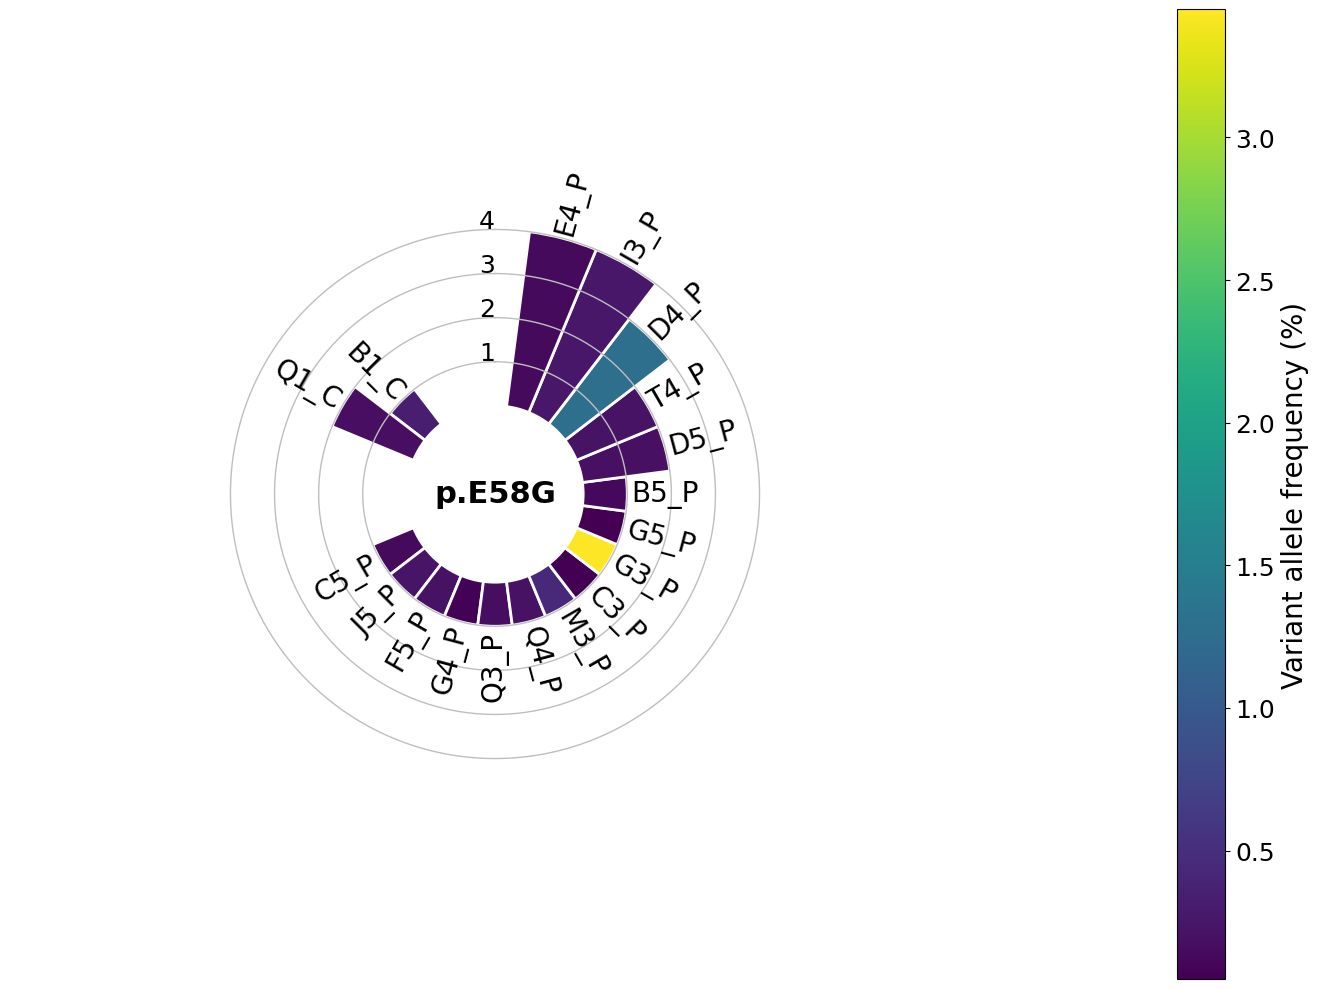

In [26]:
dfs = burden_var
dfs = dfs.sort_values(by=["group", "count"], ascending=[True, True])

VALUES = dfs["count"].values
LABELS = dfs.index.values
GROUP = dfs["group"].values
SCORES = dfs["mut_freq"].values 

PAD = 3
ANGLES_N = len(VALUES) + PAD * len(np.unique(GROUP))
ANGLES = np.linspace(0, 2 * np.pi, num=ANGLES_N, endpoint=False)
WIDTH = (2 * np.pi) / len(ANGLES)

GROUPS_SIZE = [len(i[1]) for i in dfs.groupby("group", sort=True)]
OFFSET = np.pi / 2

offset = 0
IDXS = []
for size in GROUPS_SIZE:
    IDXS += list(range(offset + PAD, offset + size + PAD))
    offset += size + PAD


COLORS = cmap(norm(SCORES))

fig, ax = plt.subplots(figsize=(20, 10), subplot_kw={"projection": "polar"})
ax.set_theta_offset(OFFSET)
ax.set_ylim(-2, 9)
ax.set_frame_on(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
ax.set_xticks([])
ax.set_yticks([])

ax.bar(
    ANGLES[IDXS], VALUES, width=WIDTH, color=COLORS, 
    edgecolor="white", linewidth=2
)
add_labels(ANGLES[IDXS], VALUES, LABELS, OFFSET, ax)

for y in [1,2,3,4]:
    ax.plot(np.linspace(0, 2 * np.pi, 500), [y] * 500, color="#bebebe", lw=1)
    ax.text(0, y + 0.2, f"{y}", color="black", fontsize=18, ha="right", va="center")

ax.text(0, -2, "p.E58G", ha='center', va='center', fontsize=22, fontweight='bold', color='black')

# Optional: Add a color bar to indicate the mapping of scores to colors
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.1, orientation='vertical')
cbar.set_label('Variant allele frequency (%)', size=20)
cbar.ax.tick_params(labelsize=18) 

plt.tight_layout()
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel2/figureD.png", dpi= 600, bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel2/figureD.svg", bbox_inches="tight", transparent=True)
plt.show()


Cells from positive control sample (N1_P) carrying the TARDBP p.R42 variant

In [27]:
var = 'chr1:11013852:G/A' #p.R42H
df_positivecontrol = NGT[NGT['sample_id'] == "N1_P"][var]
sel_barcodes= df_positivecontrol[df_positivecontrol.isin([1,2])].index
df_positivecontrol[df_positivecontrol.isin([1,2])]

NGT_FILTERED
CCTAGTCTCTCTGCGCTG-1-1    2
CTTAAGTTGAATGCAGCG-1-1    2
GACCGTAGTAATATCGCT-1-1    1
GAGTATCGCGCGCTTCTC-1-1    2
GTATGCCTTGGATGCGAA-1-1    1
TCGTTCTCCCCAACGGAA-1-1    1
Name: chr1:11013852:G/A, dtype: int8

In [28]:
# The frequency of p.R42H
af_df1 =  AF_FILTERED[AF_FILTERED['sample_id'] == "N1_P"][var]
af_df1[sel_barcodes]

NGT_FILTERED
CCTAGTCTCTCTGCGCTG-1-1    100.000000
CTTAAGTTGAATGCAGCG-1-1     96.969697
GACCGTAGTAATATCGCT-1-1     84.210526
GAGTATCGCGCGCTTCTC-1-1    100.000000
GTATGCCTTGGATGCGAA-1-1     63.636364
TCGTTCTCCCCAACGGAA-1-1     68.750000
Name: chr1:11013852:G/A, dtype: float64

In [29]:
var_df = NGT[[var, 'sample_id', 'sample_type', 'tissue']]
rows = []
for sample in list(set(var_df['sample_id'])):
    df = var_df[var_df['sample_id']== sample]
    n_cells = df.shape[0]
    freq_var = pd.DataFrame((df.iloc[:, :-3].isin([1, 2])).sum()).T
    count_genotyped = df.iloc[:, :-3].isin([0, 1, 2]).sum()[0]
    freq_var['freq'] = round((freq_var[var]/count_genotyped)*100 , 2)
    freq_var['n_cells']= n_cells
    freq_var['n_genotyped'] = count_genotyped
    freq_var.index = [sample]
    rows.append(freq_var)
freq_var = pd.concat(rows, ignore_index=False)
freq_var = freq_var[freq_var[var]>0].copy()
freq_var.columns = ['count', 'mut_freq', 'n_cells', 'n_genotyped']
freq_var['group'] = [s[-1] for s in freq_var.index]

Circular plot

In [30]:
df = freq_var.copy()
df.sort_values(by='n_cells', ascending=True, inplace=True)

In [31]:
#Define helper functions for the plot
def get_label_rotation(angle, offset):
    # Rotation must be specified in degrees :(
    rotation = np.rad2deg(angle + offset)
    if angle <= np.pi:
        alignment = "right"
        rotation = rotation + 180
    else: 
        alignment = "left"
    return rotation, alignment

def add_labels(angles, values, labels, offset, ax):
    # This is the space between the end of the bar and the label
    padding = 0.1
    # Iterate over angles, values, and labels, to add all of them.
    for angle, value, label, in zip(angles, values, labels):
        angle = angle
        # Obtain text rotation and alignment
        rotation, alignment = get_label_rotation(angle, offset)
        if value <= 5:
            val = value
        elif (value > 5) & (value < 7):
            val = 6
        else:
            val = 8
        # And finally add the text
        ax.text(
            x=angle, 
            y=val + padding, 
            s=label, 
            ha=alignment, 
            va="center", 
            rotation=rotation, 
            rotation_mode="anchor",
            fontsize=20
        ) 


In [32]:
burden_var = freq_var.copy()
burden_var['group'] = burden_var['group'].map({'P': 'FTLD-TDP type C patients', 'C': 'Controls'})


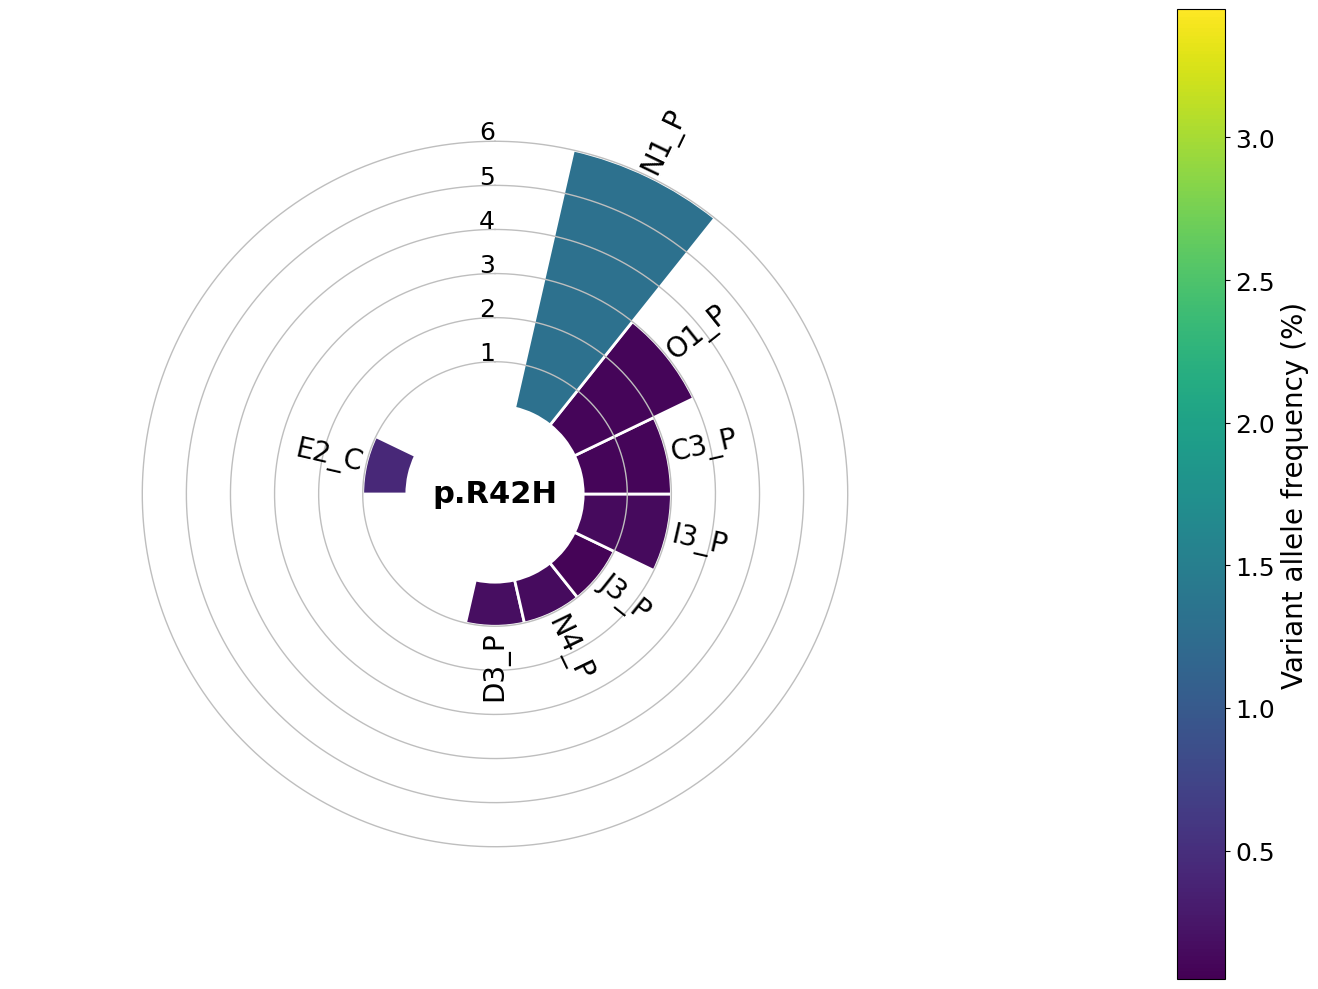

In [33]:
dfs = burden_var
dfs = dfs.sort_values(by=["group", "count"], ascending=[True, True])

VALUES = dfs["count"].values
LABELS = dfs.index.values
GROUP = dfs["group"].values
SCORES = dfs["mut_freq"].values 

PAD = 3
ANGLES_N = len(VALUES) + PAD * len(np.unique(GROUP))
ANGLES = np.linspace(0, 2 * np.pi, num=ANGLES_N, endpoint=False)
WIDTH = (2 * np.pi) / len(ANGLES)

GROUPS_SIZE = [len(i[1]) for i in dfs.groupby("group", sort=True)]
OFFSET = np.pi / 2

offset = 0
IDXS = []
for size in GROUPS_SIZE:
    IDXS += list(range(offset + PAD, offset + size + PAD))
    offset += size + PAD

# Normalize the score values
#norm = Normalize(vmin=SCORES.min(), vmax=SCORES.max())

# Choose a colormap (e.g., 'viridis', 'plasma', 'coolwarm', etc.)
cmap = plt.cm.viridis

# Map the normalized scores to colors
COLORS = cmap(norm(SCORES))

fig, ax = plt.subplots(figsize=(20, 10), subplot_kw={"projection": "polar"})
ax.set_theta_offset(OFFSET)
ax.set_ylim(-2, 9)
ax.set_frame_on(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
ax.set_xticks([])
ax.set_yticks([])

ax.bar(
    ANGLES[IDXS], VALUES, width=WIDTH, color=COLORS, 
    edgecolor="white", linewidth=2
)
add_labels(ANGLES[IDXS], VALUES, LABELS, OFFSET, ax)

for y in [1,2,3,4,5,6]:
    ax.plot(np.linspace(0, 2 * np.pi, 500), [y] * 500, color="#bebebe", lw=1)
    ax.text(0, y + 0.2, f"{y}", color="black", fontsize=18, ha="right", va="center")

ax.text(0, -2, "p.R42H", ha='center', va='center', fontsize=22, fontweight='bold', color='black')

# Optional: Add a color bar to indicate the mapping of scores to colors
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.1, orientation='vertical')
cbar.set_label('Variant allele frequency (%)', size=20)
cbar.ax.tick_params(labelsize=18) 


plt.tight_layout()
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel2/figureC.png", dpi= 600, bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel2/figureC.svg", bbox_inches="tight", transparent=True)
plt.show()
